In [1]:
import random

import cv2
import albumentations as A
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from albumentations.pytorch import ToTensorV2   
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

from torch.optim.lr_scheduler import CosineAnnealingLR


/opt/anaconda3/envs/artml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# randomness 제어를 위한 시드 고정 (학습 결과 재현을 위해 고정)
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    torch.cuda.empty_cache()


# 시드 값 선택
SEED = 42
set_seed(SEED)

# 학습 장치 결정
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(device)

mps


## Data Preprocessing

In [3]:
# 경로 설정 (kaggle 사용시)
# root_dir = '/kaggle/input/2025-dl-final/'
# save_dir = '/kaggle/working/'

# 경로 설정 (로컬 환경 사용시)
root_dir = './2025-dl-final/'
save_dir = './Model/'

In [4]:
train_dir = root_dir + 'train/'
test_dir = root_dir + 'test/'

train_csv_dir = root_dir + 'train.csv'
test_csv_dir = root_dir + 'test.csv'

In [5]:
train_df = pd.read_csv(train_csv_dir)
test_df = pd.read_csv(test_csv_dir)
train_df.head(5)

,filepath,is_ai,source,style,style_id
0,train/AI_LD_art_nouveau/0-260950338-624457.jpg,2,AI_LD,art_nouveau,0
1,train/AI_LD_art_nouveau/0-268898586-938022.jpg,2,AI_LD,art_nouveau,0
2,train/AI_LD_art_nouveau/0-277165415-252670.jpg,2,AI_LD,art_nouveau,0
3,train/AI_LD_art_nouveau/0-291212660-91900.jpg,2,AI_LD,art_nouveau,0
4,train/AI_LD_art_nouveau/0-304730701-494851.jpg,2,AI_LD,art_nouveau,0


In [6]:
test_df.head(5)

,image_id,filepath
0,1,test/00001.jpg
1,2,test/00002.jpg
2,3,test/00003.jpg
3,4,test/00004.jpg
4,5,test/00005.jpg


## Visualize Data Distribution

In [7]:
def plot_dataset_distribution(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plt.subplots_adjust(wspace=0.35)
    
    # ['human', 'AI_SD', 'AI_LD'] 히스토그램
    ai_labels = {0: "HUMAN", 1: "AI_SD", 2: "AI_LD"}
    ai_counts = df["is_ai"].value_counts().sort_index()
    axes[0].bar(ai_labels.keys(), ai_counts)
    axes[0].set_xticks(list(ai_labels.keys()))
    axes[0].set_xticklabels(list(ai_labels.values()))
    axes[0].set_title("Total is_ai Distribution")
    axes[0].set_ylabel("Image Count")
    
    # style 히스토그램
    style_counts = df["style"].value_counts().sort_index()
    axes[1].bar(style_counts.index, style_counts.values)
    axes[1].tick_params(axis='x', labelrotation=90)
    axes[1].set_title("Total Style Distribution")
    axes[1].set_xlabel("style")
    axes[1].set_ylabel("Image Count")

    grouped = df.groupby(["is_ai", "style"]).size().unstack(fill_value=0)
    grouped.T.plot(kind="bar", stacked=False, ax=axes[2], width=0.8)
    axes[2].set_title("Style Distribution by is_ai")
    axes[2].set_xlabel("style")
    axes[2].set_ylabel("Image Count")
    axes[2].legend([ai_labels[i] for i in grouped.index], title="is_ai")

    plt.suptitle("Dataset Composition Overview", fontsize=14, fontweight="bold")
    plt.show()

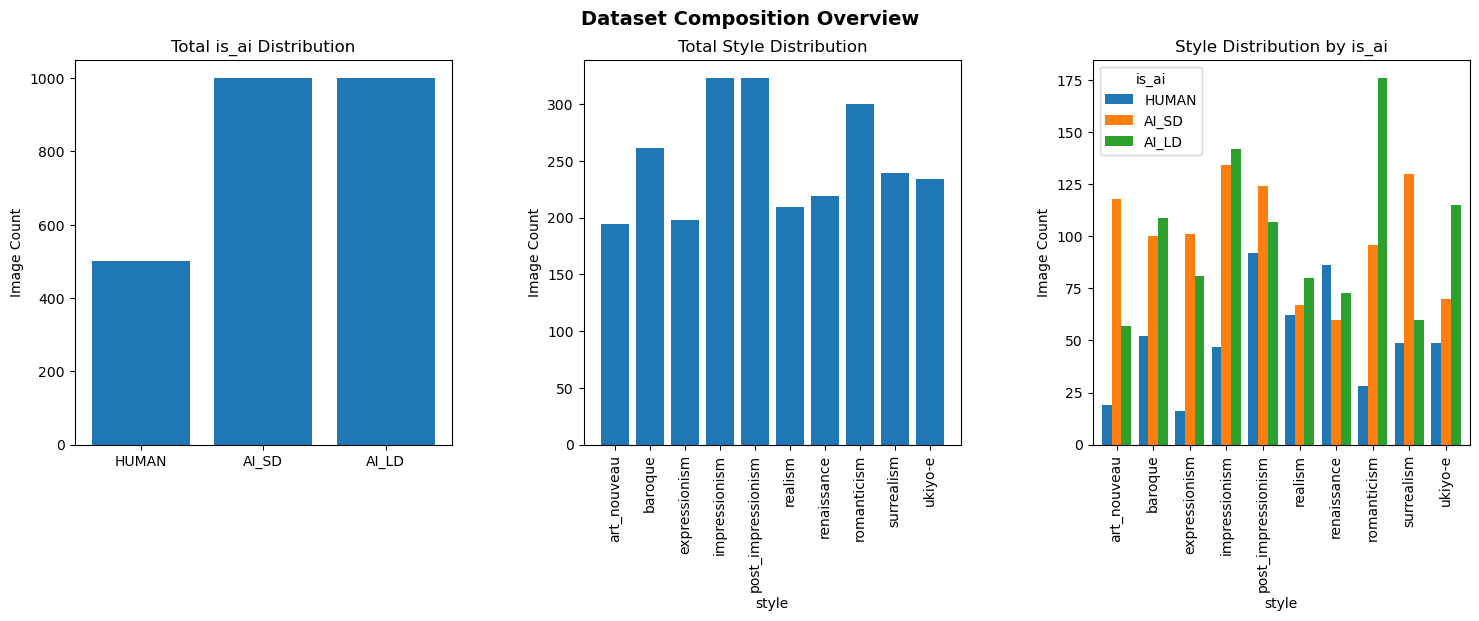

In [8]:
plot_dataset_distribution(train_df)

## Dataset & DataLoader

In [6]:
class CustomDataset(Dataset):
    
    """
    csv columns: filepath, is_ai(0/1/2), source(str), style(str), style_id(int)
    return: (image_tensor, y_ai, y_cls) or image_tensor
    """
    
    def __init__(self, df, transform=None, inference=False):
        self.df = df
        self.transform = transform
        self.inference = inference
        
        print(f'[info] Loaded {len(df)} rows')
        
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        ## csv 파일에 저장된 이미지 경로
        path = row["filepath"]
        
        ## Kaggle 사용시 해당 코드 추가
        path = root_dir + path
        
        ## 이미지 로드 후 채널 포맷 BGR -> RGB        
        image = cv2.cvtColor(cv2.imread(path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
        if image is None:
            raise FileNotFoundError(f"Failed to read image: {path}")
        
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        
        if self.inference:
            id = int(row['image_id'])
            return id, image
        
        y_ai = torch.tensor(row["is_ai"], dtype=torch.long)
        y_cls = torch.tensor(row["style_id"], dtype=torch.long)
        return image, y_ai, y_cls

In [10]:
# 평균/표준편차 확인용 임시코드
import os

means = []
stds = []

for root, _, files in os.walk(train_dir):
    for f in tqdm(files):
        if not f.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            continue

        img = cv2.imread(os.path.join(root, f))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0

        means.append(img.mean(axis=(0,1)))
        stds.append(img.std(axis=(0,1)))

mean = np.mean(means, axis=0)
std  = np.mean(stds, axis=0)

print("Dataset Mean:", mean)
print("Dataset Std:", std)

100%|█████████████████████████████████████████| 60/60 [00:00<00:00, 1120.82it/s]

Dataset Mean: [0.47378795 0.43671428 0.36343734]
Dataset Std: [0.23845276 0.21094586 0.2036343 ]


In [7]:
## 학습 때 사용할 transform 정의 ##
mean, std = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        rotate_limit=30, # 최대 30도까지 회전
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.7
    ),

    A.RandomResizedCrop(
        size=(128, 128),  # 이미지 사이즈 
        scale=(0.8, 1.0), # 원본 대비 크기 범위
        ratio=(0.9, 1.1), # 가로 / 세로 비율 변경
        p=1.0
    ),
    
    A.Normalize(mean, std),
    ToTensorV2(),
])

## 평가용 transform 정의 ##
eval_transform = A.Compose([
    #
    #
    #
    A.Normalize(mean, std),
    ToTensorV2(),
])

In [8]:
num_workers = 0

# train / validation set 분리
train_df, valid_df = train_test_split(train_df, test_size=0.2, random_state=SEED)

train_dataset = CustomDataset(train_df, transform=train_transform, inference=False)
valid_dataset = CustomDataset(valid_df, transform=eval_transform, inference=False)

test_dataset = CustomDataset(test_df, transform=eval_transform, inference=True)

[info] Loaded 2000 rows
[info] Loaded 500 rows
[info] Loaded 10000 rows


In [9]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=0)

## Visualize Image Sample
* 배치 안에서 10개의 이미지를 샘플링 하여 시각화
* transform 적용 후 이미지가 어떻게 변하는지 확인

/opt/anaconda3/envs/artml/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


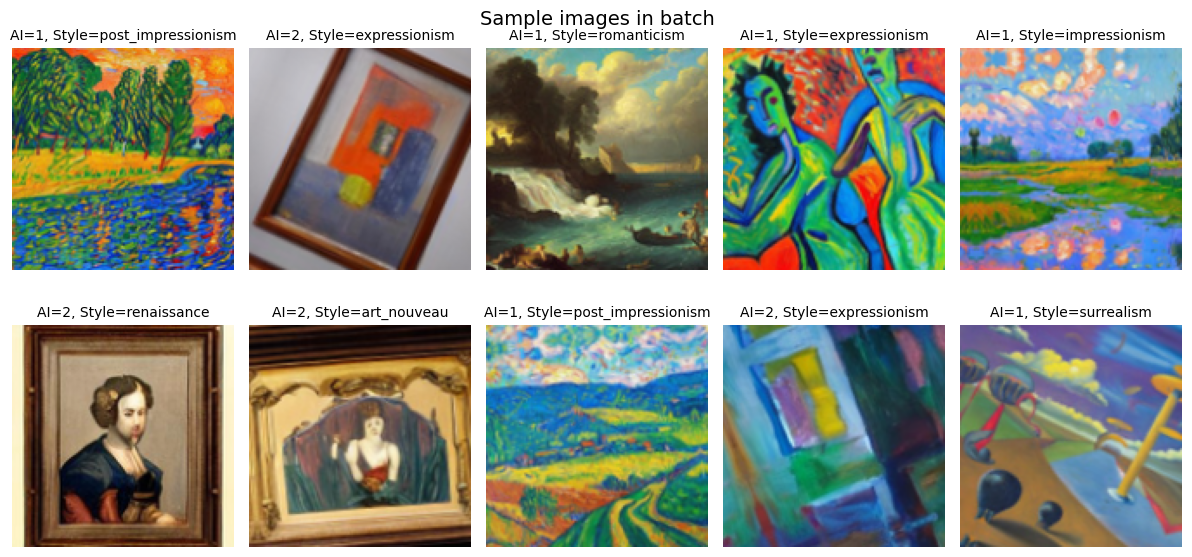

In [11]:
# Normalize 에서 쓴 값과 동일해야 함 (RGB 순서)
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)


# transform 으로 normalize 된 image tensor denormalize
def denorm(img):
    x = img.detach().cpu() * STD + MEAN
    x = x.clamp(0, 1).permute(1,2,0).numpy()
    return x

def show_batch(loader, idx2style=None):
    # 1) DataLoader가 들어오면 첫 배치를 꺼냄
    batch = next(iter(loader))
    xb, y_ai, y_cls= batch[0], batch[1], batch[2]     # (images, y_ai, y_style) 구조
    
    # y_ai를 0/1 정수로 (B,1 또는 (B,) 모두 처리)
    yb_ai_bin = y_ai.view(-1).long().tolist()
    # y_cls는 바로 int 리스트로
    yb_cls_int = y_cls.view(-1).long().tolist()
    
    plt.figure(figsize=(12, 6))
    for i in range(10):
        plt.subplot(2, 5, i+1)
        plt.imshow(denorm(xb[i]))
        style_label = yb_cls_int[i]
        style_txt = idx2style.get(style_label, str(style_label)) if idx2style else str(style_label)
        plt.axis('off')
        plt.title(f'AI={yb_ai_bin[i]}, Style={style_txt}',fontsize=10)
    plt.tight_layout()
    plt.suptitle("Sample images in batch", fontsize=14)
    plt.show()
  
show_batch(train_loader, idx2style={
    0:'art_nouveau', 1:'baroque', 2:'expressionism', 3:'impressionism',
    4:'post_impressionism', 5:'realism', 6:'renaissance', 7:'romanticism', 8:'surrealism', 9:'ukiyo-e'
})

## Model

In [12]:
# data = 3 * 128 * 128

class ArtClassifier(nn.Module):
    def __init__(self, drop_conv=0.25, drop_fc=0.5):
        super().__init__()
        
        # Convolutional layer
        self.conv1 = nn.Conv2d(3, 16, 3, stride = 1, padding = 1)    # 3 * 128 * 128 -> 8 * 128 * 128
        self.conv2 = nn.Conv2d(16, 32, 3, stride = 1, padding = 1)   # 8 * 64 * 64 -> 16 * 64 * 64
        self.conv3 = nn.Conv2d(32, 64, 3, stride = 1, padding = 1)   # 16 * 32 * 32 -> 32 * 32 * 32
        self.conv4 = nn.Conv2d(64, 128, 3, stride = 1, padding = 1)  # 32 * 16 * 16 -> 64 * 16 * 16
        self.conv5 = nn.Conv2d(128, 256, 3, stride = 1, padding = 1) # -> 256 * 8 * 8 = 8192

        # Max pooling layer
        self.pool = nn.MaxPool2d(2, stride=2)

        # Batch Normalization for conv
        self.conv1_bn = nn.BatchNorm2d(16)
        self.conv2_bn = nn.BatchNorm2d(32)
        self.conv3_bn = nn.BatchNorm2d(64)
        self.conv4_bn = nn.BatchNorm2d(128)
        self.conv5_bn = nn.BatchNorm2d(256)

        # Linear layer
        self.fc1 = nn.Linear(4096, 1024)
        self.fc2 = nn.Linear(1024, 256)
        self.fc3_source = nn.Linear(256, 3)  # output for source
        self.fc3_style = nn.Linear(256, 10)  # output for style
        
        # Dropout layer (p = 0.2 ~ 0.5)
        self.dropout_conv = nn.Dropout(drop_conv)
        self.dropout_fc = nn.Dropout(drop_fc)
        
        # ReLU
        self.relu = nn.ReLU(True)

        # Batch Normalization for FC
        self.fc1_bn = nn.BatchNorm1d(1024)
        self.fc2_bn = nn.BatchNorm1d(256)
        
    def forward(self, x):

        # Convolutional and Max pooling layers
        x = self.pool(self.relu(self.conv1_bn(self.conv1(x))))
        x = self.pool(self.relu(self.conv2_bn(self.conv2(x))))
        x = self.pool(self.relu(self.conv3_bn(self.conv3(x))))
        x = self.pool(self.relu(self.conv4_bn(self.conv4(x))))
        x = self.pool(self.relu(self.conv5_bn(self.conv5(x))))

        # Resize image
        x = x.reshape(-1, 4096)

        # Add Dropout
        x = self.dropout_conv(x)

        # FC
        x = self.dropout_fc(self.relu(self.fc1_bn(self.fc1(x))))
        x = self.dropout_fc(self.relu(self.fc2_bn(self.fc2(x))))

        # Output layers
        x_source = self.fc3_source(x)
        x_style = self.fc3_style(x)

        return x_source, x_style

model = ArtClassifier(drop_conv=0.6, drop_fc=0.8)

model.to(device)

ArtClassifier(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv1_bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4_bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5_bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=4096, out_fea

## Loss & Optimizer

In [13]:
# from torch.optim.lr_scheduler import StepLR
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion_source = nn.CrossEntropyLoss()
criterion_style = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.002, weight_decay = 0.0006)
# scheduler = StepLR(optimizer, step_size = 20, gamma = 0.5)
scheduler = CosineAnnealingLR(optimizer, T_max = 150, eta_min = 0.00001)

### 수정 1
* weight_decay 추가 (0.0001)
* BatchNorm2d & BatchNorm1d 추가
* Conv의 Dropout 강도조절

## Train & Validation

In [14]:
# Training code

n_epochs = 150

train_loss = torch.zeros(n_epochs)
train_acc_source = torch.zeros(n_epochs)
train_acc_style = torch.zeros(n_epochs)

valid_loss = torch.zeros(n_epochs)
valid_acc_source = torch.zeros(n_epochs)
valid_acc_style = torch.zeros(n_epochs)

best_epoch = -1
best_val_loss = float('inf')
best_val_src_acc = 0.0
best_val_sty_acc = 0.0

best_epoch_style = -1
best_acc_style = 0.0
best_acc_style_source_acc = 0.0
best_acc_style_loss = float('inf')

for e in range(0, n_epochs):
    model.train()
    for data, label_source, label_style in train_loader: # 배치 샘플 가져오기
        data, label_source, label_style = data.to(device), label_source.to(device), label_style.to(device)

        # gradient 초기화
        optimizer.zero_grad()

        # 네트워크 결과 가져오기
        logits_source, logits_style = model(data)

        # source, style 별 loss 계산
        loss_source = criterion_source(logits_source, label_source)
        loss_style = criterion_style(logits_style, label_style)

        # 두 loss를 합해서 그래디언트 계산
        loss = loss_source + loss_style
        loss.backward()

        # 업데이트
        optimizer.step()

        # 에폭별 loss 평균을 구하기 위해 loss저장
        train_loss[e] += loss.item()

        # 에폭별 accuracy 평균을 구하기 위해 저장(source)
        ps_source = F.softmax(logits_source, dim = 1)
        top_p_src, top_class_src = ps_source.topk(1, dim=1)
        equals = top_class_src == label_source.reshape(top_class_src.shape)
        train_acc_source[e] += torch.mean(equals.type(torch.float)).item()

        # 에폭별 accuracy 평균을 구하기 위해 저장(style)
        ps_style = F.softmax(logits_style, dim = 1)
        top_p_stl, top_class_stl = ps_style.topk(1, dim=1)
        equals = top_class_stl == label_style.reshape(top_class_stl.shape)
        train_acc_style[e] += torch.mean(equals.type(torch.float)).item()

    train_loss[e] /= len(train_loader)
    train_acc_source[e] /= len(train_loader)
    train_acc_style[e] /= len(train_loader)

    with torch.no_grad():
        model.eval()
        for data, label_source, label_style in valid_loader: # 배치 샘플 가져오기
            data, label_source, label_style = data.to(device), label_source.to(device), label_style.to(device)

             # 네트워크 결과 가져오기
            logits_source, logits_style = model(data)

            # source, style 별 loss 계산
            loss_source = criterion_source(logits_source, label_source)
            loss_style = criterion_style(logits_style, label_style)

            # 두 loss를 합
            loss = loss_source + loss_style
            valid_loss[e] += loss.item()

            # 에폭별 accuracy 평균을 구하기 위해 저장(source)
            ps_source = F.softmax(logits_source, dim = 1)
            top_p_src, top_class_src = ps_source.topk(1, dim=1)
            equals = top_class_src == label_source.reshape(top_class_src.shape)
            valid_acc_source[e] += torch.mean(equals.type(torch.float)).item()
    
            # 에폭별 accuracy 평균을 구하기 위해 저장(style)
            ps_style = F.softmax(logits_style, dim = 1)
            top_p_stl, top_class_stl = ps_style.topk(1, dim=1)
            equals = top_class_stl == label_style.reshape(top_class_stl.shape)
            valid_acc_style[e] += torch.mean(equals.type(torch.float)).item()

        valid_loss[e] /= len(valid_loader)
        valid_acc_source[e] /= len(valid_loader)
        valid_acc_style[e] /= len(valid_loader)
    
    if (valid_loss[e] < best_val_loss):
        best_val_loss = valid_loss[e].item()
        best_val_src_acc = valid_acc_source[e].item()
        best_val_sty_acc = valid_acc_style[e].item()
        best_epoch = e
        torch.save(model.state_dict(), 'best_model_statedict.pth')
        print(f">>> Best model updated at epoch {e}, val_loss={best_val_loss:.4f}")

    if (valid_acc_style[e] > best_acc_style):
        best_acc_style_loss = valid_loss[e].item()
        best_acc_style = valid_acc_style[e].item()
        best_acc_style_source_acc = valid_acc_source[e].item()
        best_epoch_style = e
        torch.save(model.state_dict(), 'best_style_acc_statedict.pth')
        print(f">>> Best style acc model updated at epoch {e}, val_loss={best_val_loss:.4f}")

    # lr 갱신
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    print('lr: {:.6f}'.format(current_lr))
    
    print('Epoch: {} \nTrain Loss: {:.6f} \tTrain Source accuracy: {:.6f} \tTrain Style accuracy: {:.6f}'.format(
        e, train_loss[e], train_acc_source[e], train_acc_style[e]))
    
    print('Valid Loss: {:.6f} \tValid Source accuracy: {:.6f} \tValid Style accuracy: {:.6f} \n----------'.format(
        valid_loss[e], valid_acc_source[e], valid_acc_style[e]))


/opt/anaconda3/envs/artml/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


>>> Best model updated at epoch 0, val_loss=2.8394
>>> Best style acc model updated at epoch 0, val_loss=2.8394
lr: 0.002000
Epoch: 0 
Train Loss: 3.422777 	Train Source accuracy: 0.499707 	Train Style accuracy: 0.141406
Valid Loss: 2.839394 	Valid Source accuracy: 0.608297 	Valid Style accuracy: 0.215787 
----------
>>> Best model updated at epoch 1, val_loss=2.7993
>>> Best style acc model updated at epoch 1, val_loss=2.7993
lr: 0.001999
Epoch: 1 
Train Loss: 2.952273 	Train Source accuracy: 0.605273 	Train Style accuracy: 0.216992
Valid Loss: 2.799257 	Valid Source accuracy: 0.665544 	Valid Style accuracy: 0.217942 
----------
>>> Best model updated at epoch 2, val_loss=2.5659
>>> Best style acc model updated at epoch 2, val_loss=2.5659
lr: 0.001998
Epoch: 2 
Train Loss: 2.769152 	Train Source accuracy: 0.641211 	Train Style accuracy: 0.271582
Valid Loss: 2.565874 	Valid Source accuracy: 0.727101 	Valid Style accuracy: 0.265625 
----------
>>> Best model updated at epoch 3, val_loss

## Loss 분석

In [15]:
print(f"\nBest epoch: {best_epoch}")
print(f"  best valid loss       : {best_val_loss:.4f}")
print(f"  best valid src acc    : {best_val_src_acc:.4f}")
print(f"  best valixd style acc  : {best_val_sty_acc:.4f}")

print(f"\nBest style epoch: {best_epoch_style}")
print(f"  best style acc loss   : {best_acc_style_loss:.4f}")
print(f"  best style source acc : {best_acc_style_source_acc:.4f}")
print(f"  best style acc        : {best_acc_style :.4f}")


Best epoch: 96
  best valid loss       : 0.8831
  best valid src acc    : 0.9723
  best valixd style acc  : 0.6716

Best style epoch: 120
  best style acc loss   : 0.9149
  best style source acc : 0.9783
  best style acc        : 0.7195


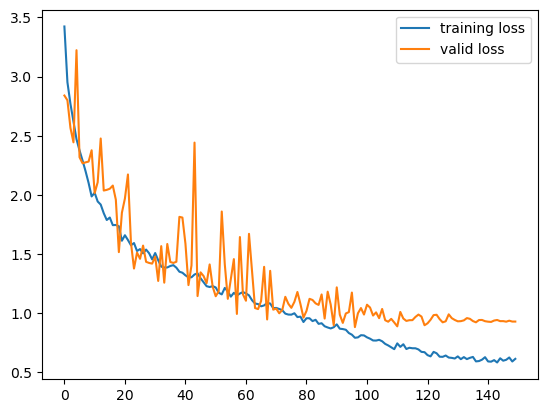

In [16]:
#
plt.plot(train_loss, label='training loss')
plt.plot(valid_loss, label='valid loss')
plt.legend()

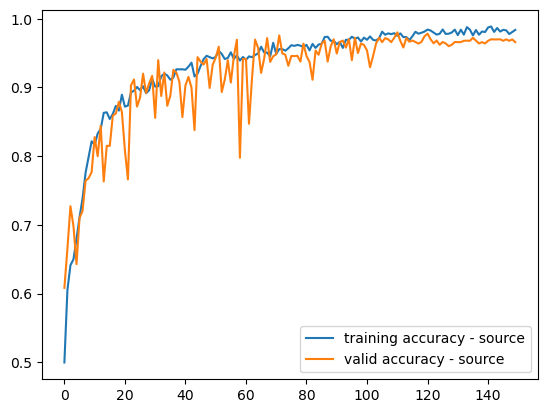

In [17]:
plt.plot(train_acc_source, label='training accuracy - source')
plt.plot(valid_acc_source, label='valid accuracy - source')
plt.legend()

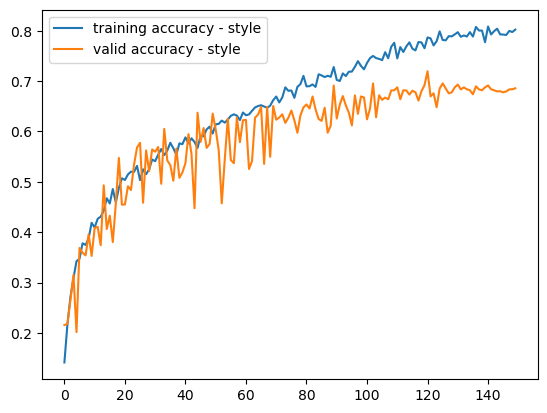

In [18]:
plt.plot(train_acc_style, label='training accuracy - style')
plt.plot(valid_acc_style, label='valid accuracy - style')
plt.legend()

## KFold

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from torch.utils.data import SubsetRandomSampler
from torch.utils.data import ConcatDataset  # 데이터셋을 합치기 위한 라이브러리

K = 5
kf = KFold(n_splits=K, shuffle=True)

full_dataset = ConcatDataset([train_dataset, valid_dataset])
batch_size = 128

In [51]:
def reset_weights(m):
     '''
       Try resetting model weights to avoid
       weight leakage.
     '''
     for layer in m.children():
         if hasattr(layer, 'reset_parameters'):
             # print(f'Reset trainable parameters of layer = {layer}')
             layer.reset_parameters()

In [80]:
# 최적 Hyperparameter 탐색 범위 지정

params = [
    # # 가장 낮은 valid loss를 보여줬었음
    # {"name": "hp1_LR(0.003)_WD(0.0005)_Dropout_conv(0.5)_Dropout_fc(0.8)",
    #  "lr": 0.003, "weight_decay": 0.0005,
    #  "drop_conv": 0.5, "drop_fc": 0.8},

    # # 여러 결과중 가장 많이 낮은 valid loss를 보임, 현재 가장 좋은 성능
    # {"name": "hp1_LR(0.002)_WD(0.00065)_Dropout_conv(0.6)_Dropout_fc(0.8)",
    #  "lr": 0.002, "weight_decay": 0.00065,
    #  "drop_conv": 0.6, "drop_fc": 0.8},

    # # 스타일 정확도 소폭 높음
    #  {"name": "hp2_LR(0.002)_WD(0.00065)_Dropout_conv(0.6)_Dropout_fc(0.75)",
    #  "lr": 0.002, "weight_decay": 0.00065,
    #  "drop_conv": 0.6, "drop_fc": 0.75},

    {"name": "hp3_LR(0.002)_WD(0.0007)_Dropout_conv(0.6)_Dropout_fc(0.75)",
     "lr": 0.002, "weight_decay": 0.0007,
     "drop_conv": 0.6, "drop_fc": 0.75},

]

In [81]:
num_epochs_per_fold = 125

# 파라미터별 결과저장
hp_results = []

# 가장 높은 sty_acc 추적
global_best_sty_acc = 0.0
global_best_sty_acc_info = None

for hp_idx, hp in enumerate(params):
    print("\n\n=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=")
    print("Parameter Set {}/{}, -> {}".format(hp_idx+1, len(params), hp['name']))

    # fold별 결과 저장
    fold_results = []  
    
    for fold, (train_ind, valid_ind) in enumerate(kf.split(full_dataset)):
        print("\n===== Starting Fold {}/{} =====".format(fold+1, K))
    
        # 데이터 분리
        train_sampler_kfold = SubsetRandomSampler(train_ind)
        valid_sampler_kfold = SubsetRandomSampler(valid_ind)
    
        train_loader_kfold = torch.utils.data.DataLoader(
            full_dataset,
            batch_size=batch_size,
            sampler=train_sampler_kfold
        )
        valid_loader_kfold = torch.utils.data.DataLoader(
            full_dataset,
            batch_size=batch_size,
            sampler=valid_sampler_kfold
        )
    
        # 모델, 옵티마이저 초기화
        model = ArtClassifier(drop_conv=hp["drop_conv"], drop_fc=hp["drop_fc"]).to(device)
        model.apply(reset_weights)
    
        criterion_source = nn.CrossEntropyLoss()
        criterion_style  = nn.CrossEntropyLoss()
    
        optimizer = optim.Adam(
            model.parameters(),
            lr=hp["lr"],
            weight_decay=hp["weight_decay"]
        )
    
        # 코사인 LR 스케줄러
        scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_per_fold, eta_min=0.00001)
    
        # loss값 저장을 위한 텐서
        train_loss = torch.zeros(num_epochs_per_fold)
        train_acc_source = torch.zeros(num_epochs_per_fold)
        train_acc_style = torch.zeros(num_epochs_per_fold)
    
        valid_loss = torch.zeros(num_epochs_per_fold)
        valid_acc_source = torch.zeros(num_epochs_per_fold)
        valid_acc_style = torch.zeros(num_epochs_per_fold)
    
        best_epoch = -1
        best_val_loss = float('inf')
        best_val_src_acc = 0.0
        best_val_sty_acc = 0.0
    
        for e in range(num_epochs_per_fold):
            model.train()
            for data, label_source, label_style in train_loader_kfold: # 배치 샘플 가져오기
                data, label_source, label_style = data.to(device), label_source.to(device), label_style.to(device)
                # gradient 초기화
                optimizer.zero_grad()
                
                # 네트워크 결과 가져오기
                logits_source, logits_style = model(data)
                
                # source, style 별 loss 계산
                loss_source = criterion_source(logits_source, label_source)
                loss_style = criterion_style(logits_style, label_style)
                
                # 두 loss를 합해서 그래디언트 계산
                loss = loss_source + loss_style
                loss.backward()
                
                # 업데이트
                optimizer.step()
    
                # 에폭별 loss 평균을 구하기 위해 loss저장
                train_loss[e] += loss.item()
    
                # 에폭별 accuracy 평균을 구하기 위해 저장(source)
                ps_source = F.softmax(logits_source, dim = 1)
                top_p_src, top_class_src = ps_source.topk(1, dim=1)
                equals = top_class_src == label_source.reshape(top_class_src.shape)
                train_acc_source[e] += torch.mean(equals.type(torch.float)).item()
    
                # 에폭별 accuracy 평균을 구하기 위해 저장(style)
                ps_style = F.softmax(logits_style, dim = 1)
                top_p_stl, top_class_stl = ps_style.topk(1, dim=1)
                equals = top_class_stl == label_style.reshape(top_class_stl.shape)
                train_acc_style[e] += torch.mean(equals.type(torch.float)).item()
    
            train_loss[e] /= len(train_loader_kfold)
            train_acc_source[e] /= len(train_loader_kfold)
            train_acc_style[e] /= len(train_loader_kfold)
    
            with torch.no_grad():
                model.eval()
                for data, label_source, label_style in valid_loader_kfold: # 배치 샘플 가져오기
                    data, label_source, label_style = data.to(device), label_source.to(device), label_style.to(device)
        
                     # 네트워크 결과 가져오기
                    logits_source, logits_style = model(data)
    
                    # source, style 별 loss 계산
                    loss_source = criterion_source(logits_source, label_source)
                    loss_style = criterion_style(logits_style, label_style)
    
                    # 두 loss를 합
                    loss = loss_source + loss_style
                    valid_loss[e] += loss.item()
    
                    # 에폭별 accuracy 평균을 구하기 위해 저장(source)
                    ps_source = F.softmax(logits_source, dim = 1)
                    top_p_src, top_class_src = ps_source.topk(1, dim=1)
                    equals = top_class_src == label_source.reshape(top_class_src.shape)
                    valid_acc_source[e] += torch.mean(equals.type(torch.float)).item()
        
                    # 에폭별 accuracy 평균을 구하기 위해 저장(style)
                    ps_style = F.softmax(logits_style, dim = 1)
                    top_p_stl, top_class_stl = ps_style.topk(1, dim=1)
                    equals = top_class_stl == label_style.reshape(top_class_stl.shape)
                    valid_acc_style[e] += torch.mean(equals.type(torch.float)).item()
                
            valid_loss[e] /= len(valid_loader_kfold)
            valid_acc_source[e] /= len(valid_loader_kfold)
            valid_acc_style[e] /= len(valid_loader_kfold)
    
            # 최고성능 모델 저장
            if (valid_loss[e] < best_val_loss):
                best_val_loss = valid_loss[e].item()
                best_val_src_acc = valid_acc_source[e].item()
                best_val_sty_acc = valid_acc_style[e].item()
                best_epoch = e
                # torch.save(model.state_dict(), 'best_model_statedict.pth')
                # print(f">>> Best model updated at epoch {e}, val_loss={best_val_loss:.4f}")

            # 최고 sty 정확도 모델 저장
            if valid_acc_style[e].item() > global_best_sty_acc:
                global_best_sty_acc = valid_acc_style[e].item()
                global_best_sty_acc_info = {
                    "hp_idx": hp_idx,
                    "hp_name": hp["name"],
                    "fold": fold,
                    "epoch": e,
                    "val_loss": valid_loss[e].item(),
                    "val_src_acc": valid_acc_source[e].item(),
                    "val_sty_acc": valid_acc_style[e].item(),
                }
            
            # lr 갱신
            scheduler.step()
    
            # print("[Fold {} | Epoch {}/{}]".format(fold+1, e, num_epochs_per_fold-1))
            # print('Epoch: {} \nTrain Loss: {:.6f} \tTrain Source accuracy: {:.6f} \tTrain Style accuracy: {:.6f}'.format(
            #     e, train_loss[e], train_acc_source[e], train_acc_style[e]))
            # print('Valid Loss: {:.6f} \tValid Source accuracy: {:.6f} \tValid Style accuracy: {:.6f} \n----------'.format(
            #     valid_loss[e], valid_acc_source[e], valid_acc_style[e]))

        # fold의 최고성능 저장
        fold_results.append({
            "fold": fold,
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            "best_val_src_acc": best_val_src_acc,
            "best_val_sty_acc": best_val_sty_acc,
        })

    # 파라미터셋의 결과
    mean_val_loss = np.mean([fr["best_val_loss"] for fr in fold_results])
    mean_val_src_acc = np.mean([fr["best_val_src_acc"] for fr in fold_results])
    mean_val_sty_acc = np.mean([fr["best_val_sty_acc"] for fr in fold_results])

    print("---------- KFold Results -> {}".format(hp["name"]))
    for fr in fold_results:
        print("Fold {}: best_epoch={}\tValid Loss: {:.4f}\tSrcAcc: {:.4f}\tStyAcc={:.4f}".format(
            fr["fold"]+1, fr["best_epoch"], fr["best_val_loss"], fr["best_val_src_acc"], fr["best_val_sty_acc"]
        ))
    print("[HP: {}] Fold mean -> Valid Loss: {:.4f}\tSrcAcc: {:.4f}\tStyAcc={:.4f}".format(
        hp["name"], mean_val_loss, mean_val_src_acc, mean_val_sty_acc
    ))

    # 파라미터별 학습 결과 저장
    hp_results.append({
        "hp_idx": hp_idx,
        "hp": hp,
        "mean_val_loss": mean_val_loss,
        "mean_val_src_acc": mean_val_src_acc,
        "mean_val_sty_acc": mean_val_sty_acc,
    })


best_hp = min(hp_results, key=lambda d: d["mean_val_loss"])
print("\nBest parameters")
print("  HP : {}".format(best_hp["hp"]))
print("  Mean style acc  : {:.6f}".format(best_hp["mean_val_sty_acc"]))
print("  Mean source acc : {:.6f}".format(best_hp["mean_val_src_acc"]))
print("  Mean val loss   : {:.6f}".format(best_hp["mean_val_loss"]))

print("\nBest style acc : {:.6f}".format(global_best_sty_acc))
print("  HP name : {}".format(global_best_sty_acc_info["hp_name"]))
print("  HP idx  : {}".format(global_best_sty_acc_info["hp_idx"]))
print("  Fold    : {}".format(global_best_sty_acc_info["fold"] + 1))
print("  Epoch   : {}".format(global_best_sty_acc_info["epoch"]))
print("  Val loss: {:.6f}".format(global_best_sty_acc_info["val_loss"]))
print("  Src acc : {:.6f}".format(global_best_sty_acc_info["val_src_acc"]))
print("  Sty acc : {:.6f}".format(global_best_sty_acc_info["val_sty_acc"]))



=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
Parameter Set 1/1, -> hp3_LR(0.002)_WD(0.0007)_Dropout_conv(0.6)_Dropout_fc(0.75)

===== Starting Fold 1/5 =====

===== Starting Fold 2/5 =====

===== Starting Fold 3/5 =====

===== Starting Fold 4/5 =====

===== Starting Fold 5/5 =====
---------- KFold Results -> hp3_LR(0.002)_WD(0.0007)_Dropout_conv(0.6)_Dropout_fc(0.75)
Fold 1: best_epoch=97	Valid Loss: 0.9610	SrcAcc: 0.9480	StyAcc=0.7136
Fold 2: best_epoch=99	Valid Loss: 0.9279	SrcAcc: 0.9738	StyAcc=0.7056
Fold 3: best_epoch=106	Valid Loss: 1.0337	SrcAcc: 0.9662	StyAcc=0.6494
Fold 4: best_epoch=100	Valid Loss: 1.0269	SrcAcc: 0.9558	StyAcc=0.6921
Fold 5: best_epoch=97	Valid Loss: 1.0352	SrcAcc: 0.9494	StyAcc=0.6863
[HP: hp3_LR(0.002)_WD(0.0007)_Dropout_conv(0.6)_Dropout_fc(0.75)] Fold mean -> Valid Loss: 0.9969	SrcAcc: 0.9586	StyAcc=0.6894

Best parameters
  HP : {'name': 'hp3_LR(0.002)_WD(0.0007)_Dropout_conv(0.6)_Dropout_fc(0.75)', 'lr': 0.002, 'weight_decay': 0.0007, 'drop_conv': 0.6, 'drop

## KFold 결과기록

### 1. Dropout_conv / Dropout_fc 가 각각 0.25 / 0.5로 설정

##### lr, wd 사용 범위
* lr 0.0003 - 0.003
* wd 0 - 0.0005

가장 낮은 Loss는 다음과 같은 파라미터에서 나타남  
##### Best parameters (by mean style acc) #####
{'name': 'hp1_LR(0.003)_WD(0.00025)', 'lr': 0.003, 'weight_decay': 0.00025, 'drop_conv': 
0.25, 'drop_fc': 0.5}  
Mean style acc : 0.612770426273346  
Mean source acc: 0.918359375  
Mean val loss  : 1.3188171148300172  
성능 매우 낮음, 평균적으로 1.3의 validation loss를 보이며, 최대 1.25보다 낮아지지 못함
-> 매우 높은 오버피팅, 더 높고 강한 제한이 필요

### 2. Dropout 강화 (conv - 0.5, fc - 0.7)
전체적으로 epoch 수를 늘린다면 valid loss가 더 크게 줄어들 가능성이 있음

---------- KFold Results -> hp1_LR(0.003)_WD(0.00025)_Dropout_conv(0.5)_Dropout_fc(0.7)  
Fold 0: best_epoch=30	Valid Loss: 1.0203	SrcAcc: 0.9494	StyAcc=0.6726  
Fold 1: best_epoch=28	Valid Loss: 1.0694	SrcAcc: 0.9392	StyAcc=0.6774  
Fold 2: best_epoch=30	Valid Loss: 1.0603	SrcAcc: 0.9444	StyAcc=0.6968  
Fold 3: best_epoch=30	Valid Loss: 1.0458	SrcAcc: 0.9337	StyAcc=0.6958  
Fold 4: best_epoch=30	Valid Loss: 1.0728	SrcAcc: 0.9479	StyAcc=0.6535  
valid loss mean => 1.05372
  
---------- KFold Results -> hp2_LR(0.003)_WD(0.0005)_Dropout_conv(0.5)_Dropout_fc(0.7)  => 가장 높은 sty_acc를 가짐, 평균적으로 가장 낮은 validation  
Fold 0: best_epoch=28	Valid Loss: 1.0704	SrcAcc: 0.9468	StyAcc=0.6755  
Fold 1: best_epoch=30	Valid Loss: 0.9414	SrcAcc: 0.9494	StyAcc=0.7067  
Fold 2: best_epoch=28	Valid Loss: 1.0630	SrcAcc: 0.9542	StyAcc=0.6725  
Fold 3: best_epoch=30	Valid Loss: 1.0710	SrcAcc: 0.9533	StyAcc=0.6810  
Fold 4: best_epoch=25	Valid Loss: 1.0552	SrcAcc: 0.9444	StyAcc=0.6414  
valid loss mean => 1.0402

---------- KFold Results -> hp3_LR(0.001)_WD(0.00025)_Dropout_conv(0.5)_Dropout_fc(0.7)  
Fold 0: best_epoch=30	Valid Loss: 1.0391	SrcAcc: 0.9527	StyAcc=0.6641  
Fold 1: best_epoch=30	Valid Loss: 1.1626	SrcAcc: 0.9337	StyAcc=0.6490  
Fold 2: best_epoch=25	Valid Loss: 1.1101	SrcAcc: 0.9322	StyAcc=0.6528  
Fold 3: best_epoch=30	Valid Loss: 0.9706	SrcAcc: 0.9537	StyAcc=0.6812  
Fold 4: best_epoch=28	Valid Loss: 1.0000	SrcAcc: 0.9492	StyAcc=0.6767  
valid loss mean => 1.0565

Best parameters  
  HP : {'name': 'hp12_LR(0.003)_WD(0.0005)_Dropout_conv(0.5)_Dropout_fc(0.8)', 'lr': 0.003, 'weight_decay': 0.0005, 'drop_conv': 0.5, 'drop_fc': 0.8}  
  Mean style acc  : 0.682572  
  Mean source acc : 0.960186  
  Mean val loss   : 0.980483  

Best style acc : 0.717248  
  HP name : hp12_LR(0.003)_WD(0.0005)_Dropout_conv(0.5)_Dropout_fc(0.8)  
  HP idx  : 11  
  Fold    : 4  
  Epoch   : 56  
  Val loss: 0.954331  
  Src acc : 0.949820  
  Sty acc : 0.717248  


### Dropout, WD 더 크게

Best parameters  
  HP : {'name': 'hp6_LR(0.002)_WD(0.00065)_Dropout_conv(0.6)_Dropout_fc(0.8)', 'lr': 0.002, 'weight_decay': 0.00065, 'drop_conv': 0.6, 'drop_fc': 0.8}  
  Mean style acc  : 0.680469  
  Mean source acc : 0.959435  
  Mean val loss   : 1.011460  

### Batch Size 조절 (512 -> 64 -> 128)

Best parameters  
  HP : {'name': 'hp2_LR(0.002)_WD(0.00065)_Dropout_conv(0.6)_Dropout_fc(0.8)', 'lr': 0.002, 'weight_decay': 0.00065, 'drop_conv': 0.6, 'drop_fc': 0.8}  
  Mean style acc  : 0.682462  
  Mean source acc : 0.963685  
  Mean val loss   : 0.958311  


### Dropout 변화

동일한 파라미터가 여전히 가장 높은 valid loss를 가짐

Best parameters  
  HP : {'name': 'hp1_LR(0.002)_WD(0.00065)_Dropout_conv(0.6)_Dropout_fc(0.8)', 'lr': 0.002, 'weight_decay': 0.00065, 'drop_conv': 0.6, 'drop_fc': 0.8}  
  Mean style acc  : 0.674151  
  Mean source acc : 0.960830  
  Mean val loss   : 0.990916  


이 경우가 스타일 정확도가 소폭 증가
---------- KFold Results -> hp2_LR(0.002)_WD(0.00065)_Dropout_conv(0.6)_Dropout_fc(0.75)  
Fold 1: best_epoch=110	Valid Loss: 0.9708	SrcAcc: 0.9502	StyAcc=0.6982  
Fold 2: best_epoch=106	Valid Loss: 1.0851	SrcAcc: 0.9580	StyAcc=0.6812  
Fold 3: best_epoch=115	Valid Loss: 1.0856	SrcAcc: 0.9496	StyAcc=0.6847  
Fold 4: best_epoch=118	Valid Loss: 0.9897	SrcAcc: 0.9584	StyAcc=0.6982  
Fold 5: best_epoch=124	Valid Loss: 0.9297	SrcAcc: 0.9599	StyAcc=0.7183  
[HP: hp2_LR(0.002)_WD(0.00065)_Dropout_conv(0.6)_Dropout_fc(0.75)] Fold mean -> Valid Loss: 1.0122	SrcAcc: 0.9552	StyAcc=0.6961  

In [ ]:
# Validation code

## 최적 파라미터별 학습

In [28]:
full_dataset = ConcatDataset([train_dataset, valid_dataset])
batch_size = 128

full_loader = DataLoader(
    full_dataset,
    batch_size=batch_size,
    shuffle=True
)

In [36]:
# 모델 생성

model = ArtClassifier(drop_conv=0.6, drop_fc=0.8).to(device)

criterion_source = nn.CrossEntropyLoss()
criterion_style  = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.002,
    weight_decay=0.00065
)

num_epochs = 113

# 코사인 LR 스케줄러
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=0.00001)

In [37]:
# 학습 수행 

for e in range(num_epochs):
    model.train()
    for data, label_source, label_style in full_loader:
        data, label_source, label_style = data.to(device), label_source.to(device), label_style.to(device)

        optimizer.zero_grad()

        logits_source, logits_style = model(data)

        loss_source = criterion_source(logits_source, label_source)
        loss_style  = criterion_style(logits_style,  label_style)
        loss = loss_source + loss_style
        loss.backward()
        optimizer.step()

    scheduler.step()

torch.save(model.state_dict(), 'model_hp1_statedict.pth')
print("Model saved")

Model saved


In [19]:
# 앙상블용 모델
model1 = ArtClassifier(drop_conv=0.6, drop_fc=0.8).to(device)
state1 = torch.load("model_hp1_statedict.pth", map_location=device)
model1.load_state_dict(state1)
model1.eval()

model1_2 = ArtClassifier(drop_conv=0.6, drop_fc=0.8).to(device)
state1 = torch.load("model_hp1_2_statedict.pth", map_location=device)
model1.load_state_dict(state1)
model1.eval()

model1_3 = ArtClassifier(drop_conv=0.6, drop_fc=0.8).to(device)
state1 = torch.load("model_hp1_3_statedict.pth", map_location=device)
model1.load_state_dict(state1)
model1.eval()

model2 = ArtClassifier(drop_conv=0.6, drop_fc=0.75).to(device)
state2 = torch.load("model_hp2_statedict.pth", map_location=device)
model2.load_state_dict(state2)
model2.eval()

model2_2 = ArtClassifier(drop_conv=0.6, drop_fc=0.75).to(device)
state2 = torch.load("model_hp2_2_statedict.pth", map_location=device)
model2.load_state_dict(state2)
model2.eval()

model2_3 = ArtClassifier(drop_conv=0.6, drop_fc=0.75).to(device)
state2 = torch.load("model_hp2_3_statedict.pth", map_location=device)
model2.load_state_dict(state2)
model2.eval()

models = [model1, model2]

In [37]:
# best 모델 적용
# state_dict = torch.load('best_model_statedict.pth') # state dict 불러오기 
# print(state_dict.keys())

odict_keys(['conv1.weight', 'conv1.bias', 'conv2.weight', 'conv2.bias', 'conv3.weight', 'conv3.bias', 'conv4.weight', 'conv4.bias', 'conv5.weight', 'conv5.bias', 'conv1_bn.weight', 'conv1_bn.bias', 'conv1_bn.running_mean', 'conv1_bn.running_var', 'conv1_bn.num_batches_tracked', 'conv2_bn.weight', 'conv2_bn.bias', 'conv2_bn.running_mean', 'conv2_bn.running_var', 'conv2_bn.num_batches_tracked', 'conv3_bn.weight', 'conv3_bn.bias', 'conv3_bn.running_mean', 'conv3_bn.running_var', 'conv3_bn.num_batches_tracked', 'conv4_bn.weight', 'conv4_bn.bias', 'conv4_bn.running_mean', 'conv4_bn.running_var', 'conv4_bn.num_batches_tracked', 'conv5_bn.weight', 'conv5_bn.bias', 'conv5_bn.running_mean', 'conv5_bn.running_var', 'conv5_bn.num_batches_tracked', 'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3_source.weight', 'fc3_source.bias', 'fc3_style.weight', 'fc3_style.bias', 'fc1_bn.weight', 'fc1_bn.bias', 'fc1_bn.running_mean', 'fc1_bn.running_var', 'fc1_bn.num_batches_tracked', 'fc2_bn.weight',

In [38]:
# model.load_state_dict(state_dict) # state_dict의 파라미터 등을 모델에 덮어씌움

<All keys matched successfully>

In [21]:
# # 모델 저장

torch.save(model2, 'model2_save.pt')

## Test & 결과제출

In [18]:
def test(model, test_loader):
    ids = []
    pred_ai = []
    pred_style = []
    
    
    for m in models:
        m.eval()
    
    with torch.no_grad():
        pbar = tqdm(test_loader, desc='[test]', leave=False)
        for image_id, image in pbar:
            image_id, image = image_id, image.to(device)

            sum_ai_probs = None
            sum_style_probs = None

            for m in models:
                logit_ai, logit_cls = m(image)

                probs_ai = F.softmax(logit_ai, dim=1)
                probs_cls = F.softmax(logit_cls, dim=1)

                if sum_ai_probs is None:
                    sum_ai_probs = probs_ai.clone()
                    sum_cls_probs = probs_cls.clone()
                else:
                    sum_ai_probs += probs_ai
                    sum_cls_probs += probs_cls

            mean_ai_probs = sum_ai_probs / len(models)
            mean_cls_probs = sum_cls_probs / len(models)
            
            ai_pred = mean_ai_probs.argmax(dim=1).cpu().tolist()
            cls_pred = mean_cls_probs.argmax(dim=1).cpu().tolist()
            
            pred_ai.extend(ai_pred)
            pred_style.extend(cls_pred)
            ids.extend([int(x) for x in image_id])
            
    sub = pd.DataFrame({
        'image_id': ids,
        'is_ai': pred_ai,
        'style_id': pred_style
    }).sort_values("image_id").reset_index(drop=True)
    
    sub.to_csv('submission.csv', index=False)
    return sub

In [39]:
# model = torch.load('model_save.pt', weights_only=False)
# model = model.to(device)

sub = test(models, test_loader)
print(sub.head(5))

[test]:   0%|                                            | 0/79 [00:00<?, ?it/s]/opt/anaconda3/envs/artml/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
                                                                                

   image_id  is_ai  style_id
0         1      2         0
1         2      2         0
2         3      2         1
3         4      2         0
4         5      2         0
